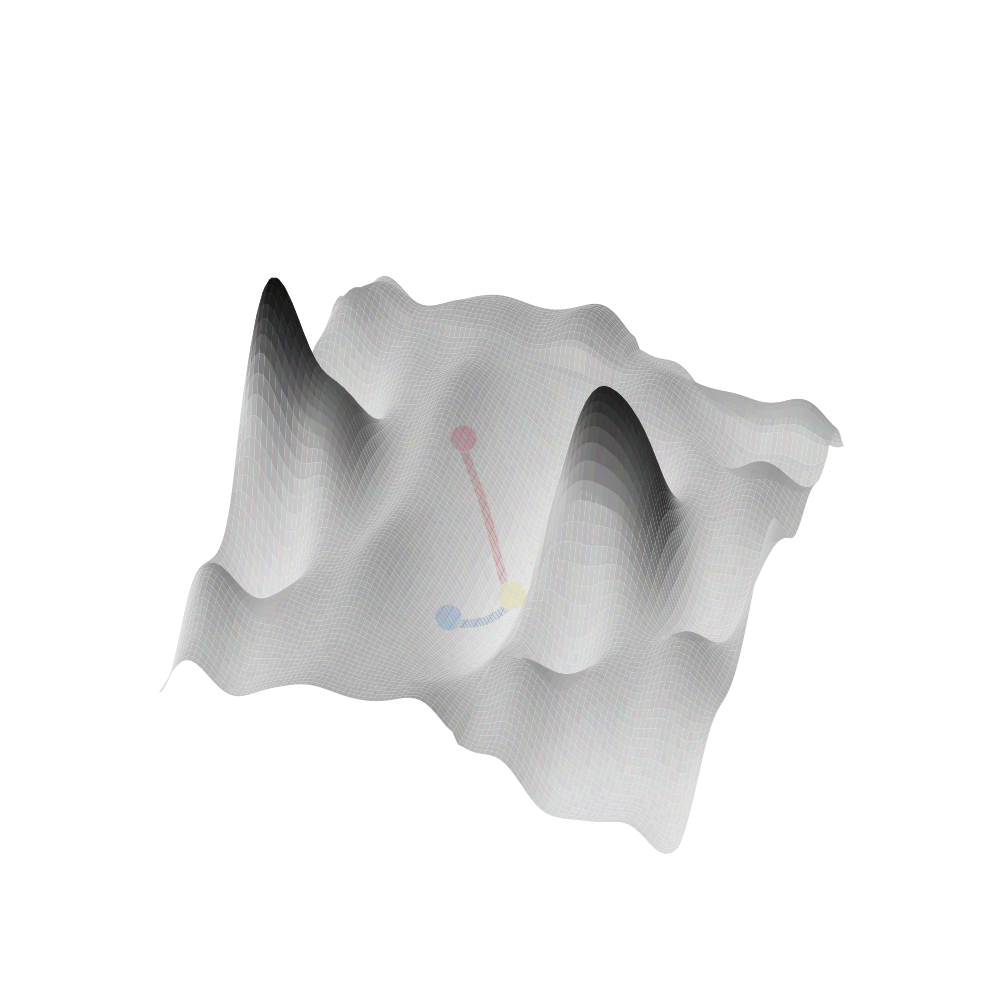

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.interpolate import RegularGridInterpolator

# =========================================
# 1. Setup Grid
# =========================================
N = 100
x = np.arange(1, N + 1)
y = np.arange(1, N + 1)
x, y = np.meshgrid(x, y)

np.random.seed(42)

# =========================================
# 2. Generate Energy Landscape
# =========================================
noise1 = 2 * np.random.rand(1, N)
noise2 = 2 * np.random.rand(1, N)

z_raw = ((np.sin(5*x/N) + 1) * (np.cos(15*y/N) - 1) + noise1) * \
        ((np.cos(5*y/N) - 1) * (np.sin(15*x/N) + 1) + noise2)

# =========================================
# 3. FFT Low-Pass Filter (Smooth Landscape)
# =========================================
zz = np.fft.fft2(z_raw)
zzz = np.zeros_like(zz)

n = 8
zzz[:n, :n] = zz[:n, :n]
zzz[-n:, :n] = zz[-n:, :n]
zzz[:n, -n:] = zz[:n, -n:]
zzz[-n:, -n:] = zz[-n:, -n:]

z_filtered = np.real(np.fft.ifft2(zzz))
z_filtered = gaussian_filter(z_filtered, sigma=1.3)

# =========================================
# 4. MOVE GLOBAL MINIMUM TO GRID CENTER
# =========================================
min_idx = np.unravel_index(np.argmin(z_filtered), z_filtered.shape)

center = (N // 2, N // 2)
shift_i = center[0] - min_idx[0]
shift_j = center[1] - min_idx[1]

z_centered = np.roll(z_filtered, shift=(shift_i, shift_j), axis=(0, 1))

# Rebuild centered coordinate system
x_centered = x - x[center]
y_centered = y - y[center]

# Shift energy zero
z_shift = z_centered - z_centered.min()
z_span = z_shift.max() - z_shift.min()

# =========================================
# 5. Initial Guess States (unchanged offsets)
# =========================================
idx_good = (center[0] - 20, center[1] - 5)
idx_bad  = (center[0] + 12, center[1] - 14)

xg, yg, zg = x_centered[idx_good], y_centered[idx_good], z_shift[idx_good]
xb, yb, zb = x_centered[idx_bad],  y_centered[idx_bad],  z_shift[idx_bad]

# =========================================
# 6. Continuous Interpolator
# =========================================
interp = RegularGridInterpolator(
    (y_centered[:, 0], x_centered[0]),
    z_shift,
    bounds_error=False,
    fill_value=None
)

# =========================================
# 7. Smooth Convergence Paths
# =========================================
def smooth_path(x0, y0, curvature, npts=220):
    t = np.linspace(0, 1, npts)

    cx = (1 - t) * x0 + curvature * np.sin(np.pi * t)
    cy = (1 - t) * y0 - curvature * np.sin(np.pi * t)

    pts = np.vstack([cy, cx]).T
    cz = interp(pts)
    cz = gaussian_filter1d(cz, sigma=6)

    return cx, cy, cz

path_good = smooth_path(xg, yg, curvature=0.15)
path_bad  = smooth_path(xb, yb, curvature=0.45)

# =========================================
# 8. Plot — Dark metallic surface + red/yellow/blue path
# =========================================
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')

# Dark metallic: light from upper-left, strong specular highlights (overlay)
ls = LightSource(azdeg=315, altdeg=35)
rgb = ls.shade(
    z_shift,
    cmap=plt.cm.Greys,
    vert_exag=0.22,
    blend_mode='overlay'
)
# Dark base with bright highlights for metallic sheen
rgb = np.clip(rgb * 0.82 + 0.06, 0, 1)
# Subtle brushed-metal variation (fine striations)
np.random.seed(1)
rgb = np.clip(rgb + 0.03 * (np.random.rand(*rgb.shape) - 0.5), 0, 1)

ax.plot_surface(
    x_centered, y_centered, z_shift,
    facecolors=rgb,
    rstride=1, cstride=1,
    alpha=0.95,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Contour lines as subtle light ridges on the dark surface
ax.contour(
    x_centered, y_centered, z_shift,
    levels=15, colors='white',
    alpha=0.25, linewidths=0.6,
    zdir='z', offset=0
)

# =========================================
# 9. Path: red sphere → yellow → blue sphere (red rod, blue rod)
# =========================================
path_lift = 0.02 * z_span
marker_lift = 0.05 * z_span

# Red rod: (xb,yb) → (0,0)   and   Blue rod: (0,0) → (xg,yg)
path_red = path_bad   # from bad start to global min
path_blue = (path_good[0][::-1], path_good[1][::-1], path_good[2][::-1])  # from global min to good start

ax.plot(path_red[0], path_red[1], path_red[2] + path_lift,
        color='#cc0000', linewidth=6.0, alpha=0.95)
ax.plot(path_blue[0], path_blue[1], path_blue[2] + path_lift,
        color='#0044aa', linewidth=6.0, alpha=0.95)

# Three glossy spheres: red (back), yellow (middle), blue (front)
ax.scatter(xb, yb, zb + marker_lift,
           s=380, color='#ff0033',
           edgecolors='white', linewidth=0.8)

ax.scatter(0, 0, marker_lift,
           s=420, color='#ffdd00',
           edgecolors='white', linewidth=0.8)

ax.scatter(xg, yg, zg + marker_lift,
           s=380, color='#0080ff',
           edgecolors='white', linewidth=0.8)

# =========================================
# 10. View — upper-left lighting, white background
# =========================================
ax.set_facecolor('white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.view_init(elev=50, azim=-70)
ax.set_axis_off()

plt.tight_layout()
plt.show()